<a href="https://colab.research.google.com/github/vutungduong0-art/LAB01/blob/main/Buoi2_BTTH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Khai báo đường dẫn tới file dữ liệu
file_path = '/content/drive/MyDrive/Bài tập đh/HocMay/Du_lieu_thuc_hanh_chuan_bi_du_lieu.xlsx'

print('Đã mount Drive và lưu đường dẫn file thành công!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã mount Drive và lưu đường dẫn file thành công!


In [10]:
# Bai 1: Import pandas, numpy, matplotlib.pyplot và seaborn.
# Đọc sheet Du_lieu_tho từ tệp Excel.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Đọc dữ liệu từ sheet Du_lieu_tho
df = pd.read_excel(file_path, sheet_name='Du_lieu_tho')
print('Đã đọc sheet Du_lieu_tho thành công!')

Đã đọc sheet Du_lieu_tho thành công!


In [11]:
# Bai 1: Hiển thị 5 dòng đầu, 5 dòng cuối, kích thước và danh sách cột.

print('=== 5 DÒNG ĐẦU ===')
display(df.head())

print('\n=== 5 DÒNG CUỐI ===')
display(df.tail())

print(f'\nKích thước dữ liệu (Rows, Columns): {df.shape}')

print('\n=== DANH SÁCH CỘT ===')
print(df.columns.tolist())

=== 5 DÒNG ĐẦU ===


,Product_ID,Product_Name,Category,Price_VND,Rating,Purchase_Count,Stock,Seller_City,Created_Date,Weight,Description,Has_Image,Discount,Target_High_Sales
0,SP0001,Giày thể thao B2,Thời trang,625000,3.2,2290,140,Nam Định,2026-07-17 00:00:00,1509,"Giao hàng nhanh, đóng gói cẩn thận",Có,0,0
1,SP0002,Cơ sở dữ liệu C3,Sách,377000,3.9,1405,107,Đà Nẵng,2026-05-26 00:00:00,754,Chất lượng tốt trong tầm giá,Có,0,0
2,SP0003,Áo sơ mi D4,Thời trang,1039000,3.6,1081,87,Đà Nẵng,2026-05-06 00:00:00,989,NaN,Có,0.25,0
3,SP0004,Khoa học dữ liệu E1,Sách,824000,4.4,323,84,Hải Phòng,2026-08-18 00:00:00,416,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",Có,0.15,0
4,SP0005,Bàn phím cơ A2,Điện tử,NaN,3.9,1655,190,TP. Hồ Chí Minh,2026-04-11 00:00:00,137,"Giao hàng nhanh, đóng gói cẩn thận",Có,0.25,0



=== 5 DÒNG CUỐI ===


,Product_ID,Product_Name,Category,Price_VND,Rating,Purchase_Count,Stock,Seller_City,Created_Date,Weight,Description,Has_Image,Discount,Target_High_Sales
223,SP0120,Python cơ bản A1,Sách,1674000,3.9,238,315,Bắc Ninh,2026-05-14 00:00:00,971,"Sản phẩm chính hãng, bảo hành 12 tháng",Có,0.25,0
224,SP0159,Túi đeo chéo E4,Thời trang,205000,4.3,469,59,Hà Nội,2026-01-11 00:00:00,926,Chất lượng tốt trong tầm giá,Không,0.2,0
225,SP0072,Bản sao mã sản phẩm,Thời trang,1103000,4.9,1098,189,TP. Hồ Chí Minh,2026-05-20 00:00:00,1003,"Giao hàng nhanh, đóng gói cẩn thận",Có,0.2,1
226,SP0180,Cơ sở dữ liệu B2,Sách,1234000,3.5,1036,228,Cần Thơ,2026-06-23 00:00:00,1561,Chất lượng tốt trong tầm giá,Không,0.15,0
227,SP0210,Sạc dự phòng B4,Điện tử,1683000,3.5,619,169,HN,2026-07-27 00:00:00,506,"Phiên bản mới, nhiều màu lựa chọn",Có,0.25,0



Kích thước dữ liệu (Rows, Columns): (228, 14)

=== DANH SÁCH CỘT ===
['Product_ID', 'Product_Name', 'Category', 'Price_VND', 'Rating', 'Purchase_Count', 'Stock', 'Seller_City', 'Created_Date', 'Weight', 'Description', 'Has_Image', 'Discount', 'Target_High_Sales']


guyên nhân chính khiến các cột mang bản chất dữ liệu số hoặc ngày tháng như Price_VND, Rating, Purchase_Count, Created_Date hay Weight bị Pandas nhận diện thành kiểu object (chuỗi ký tự) là do trong cột xuất hiện ít nhất một giá trị không đúng chuẩn định dạng số/ngày (chứa ký tự chữ, ký tự đặc biệt hoặc văn bản nhập tay). Khi đọc dữ liệu, Pandas sẽ tự động ép kiểu toàn bộ cột về object để đảm bảo không bị mất thông tin.

3 giá trị cụ thể trong thực tế làm cột bị sai kiểu:

Chuỗi nhập báo thiếu/không xác định:

Giá trị ví dụ: "N/A", "chưa rõ", "không" hoặc dấu gạch ngang "-".

Tác động: Chỉ cần một dòng trong cột Price_VND hoặc Weight mang giá trị này, Pandas lập tức chuyển cả cột thành object.

Ký tự định dạng / Đơn vị tính đi kèm:

Giá trị ví dụ: "1.500.000 VNĐ" (chứa chữ VNĐ), "2.5 kg" (chứa chữ kg), hoặc "5,0" (dùng dấu phẩy phân cách số thập phân dạng text).

Tác động: Ký tự đơn vị hoặc dấu phân cách sai định dạng chuẩn khiến cột Price_VND, Weight hay Rating không thể convert thành kiểu float hay int.

Văn bản hoặc Ngày tháng không hợp lệ:

Giá trị ví dụ: "2026/02/31" (ngày không tồn tại) hoặc "Chưa giao" nhập vào cột Created_Date.

Tác động: Trình phân tích ngày tháng (datetime parser) không đọc được giá trị này dưới dạng thời gian chuẩn nên sẽ trả về kiểu object.

In [7]:
#Bai 2 Tính số lượng và tỷ lệ thiếu theo từng cột, sắp xếp giảm dần.

import pandas as pd

# 1. Đọc dữ liệu từ sheet 'Du_lieu_tho' (hoặc đọc file nếu không chia sheet)
try:
  df = pd.read_excel(file_path, sheet_name='Du_lieu_tho')
except Exception:
  df = pd.read_excel(file_path)

# 2. Tính số lượng và tỷ lệ dữ liệu thiếu theo từng cột
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# 3. Tạo bảng thống kê và sắp xếp giảm dần theo tỷ lệ thiếu
bao_cao_thieu = pd.DataFrame({
    'Số lượng thiếu': missing_count,
    'Tỷ lệ thiếu (%)': missing_percent.round(2),
}).sort_values(by='Tỷ lệ thiếu (%)', ascending=False)

print('=== THỐNG KÊ DỮ LIỆU THIẾU THEO TỪNG CỘT (GIẢM DẦN) ===')
display(bao_cao_thieu)

=== THỐNG KÊ DỮ LIỆU THIẾU THEO TỪNG CỘT (GIẢM DẦN) ===


,Số lượng thiếu,Tỷ lệ thiếu (%)
Description,15,6.58
Rating,13,5.70
Price_VND,9,3.95
Seller_City,7,3.07
Created_Date,6,2.63
Product_Name,0,0.00
Purchase_Count,0,0.00
Category,0,0.00
Product_ID,0,0.00
Stock,0,0.00


In [8]:
#Bai 2 Đếm dòng trùng hoàn toàn bằng duplicated().

# 1. Đếm tổng số dòng bị trùng hoàn toàn (tất cả các cột giống hệt nhau)
so_dong_trung = df.duplicated().sum()
print(f"Số lượng dòng trùng hoàn toàn: {so_dong_trung} dòng")

# 2. Hiển thị các dòng bị trùng hoàn toàn (nếu có) để kiểm tra
if so_dong_trung > 0:
    print("\nDanh sách các dòng trùng hoàn toàn:")
    display(df[df.duplicated(keep=False)])
else:
    print("Không có dòng nào bị trùng lặp hoàn toàn.")

Số lượng dòng trùng hoàn toàn: 5 dòng

Danh sách các dòng trùng hoàn toàn:


,Product_ID,Product_Name,Category,Price_VND,Rating,Purchase_Count,Stock,Seller_City,Created_Date,Weight,Description,Has_Image,Discount,Target_High_Sales
11,SP0012,Máy hút bụi C1,Gia dụng,1247000,4.8,1530,80,Bắc Ninh,2026-01-14 00:00:00,1774,"Phiên bản mới, nhiều màu lựa chọn",Không,0.2,1
48,SP0049,Cơ sở dữ liệu E2,Sách,1138000,4.6,1874,72,Cần Thơ,2026-04-08 00:00:00,1713,Chất lượng tốt trong tầm giá,Có,0,1
87,SP0088,Máy xay sinh tố D1,Gia dụng,395000,3.4,1081,111,Bắc Ninh,2026-04-13 00:00:00,1733,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",Không,0.15,0
119,SP0120,Python cơ bản A1,Sách,1674000,3.9,238,315,Bắc Ninh,2026-05-14 00:00:00,971,"Sản phẩm chính hãng, bảo hành 12 tháng",Có,0.25,0
158,SP0159,Túi đeo chéo E4,Thời trang,205000,4.3,469,59,Hà Nội,2026-01-11 00:00:00,926,Chất lượng tốt trong tầm giá,Không,0.2,0
220,SP0012,Máy hút bụi C1,Gia dụng,1247000,4.8,1530,80,Bắc Ninh,2026-01-14 00:00:00,1774,"Phiên bản mới, nhiều màu lựa chọn",Không,0.2,1
221,SP0049,Cơ sở dữ liệu E2,Sách,1138000,4.6,1874,72,Cần Thơ,2026-04-08 00:00:00,1713,Chất lượng tốt trong tầm giá,Có,0,1
222,SP0088,Máy xay sinh tố D1,Gia dụng,395000,3.4,1081,111,Bắc Ninh,2026-04-13 00:00:00,1733,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",Không,0.15,0
223,SP0120,Python cơ bản A1,Sách,1674000,3.9,238,315,Bắc Ninh,2026-05-14 00:00:00,971,"Sản phẩm chính hãng, bảo hành 12 tháng",Có,0.25,0
224,SP0159,Túi đeo chéo E4,Thời trang,205000,4.3,469,59,Hà Nội,2026-01-11 00:00:00,926,Chất lượng tốt trong tầm giá,Không,0.2,0


In [9]:
#Bai 2 Phân biệt trùng hoàn toàn và trùng khóa. Không xóa trước khi quan sát.

# 1. Trùng hoàn toàn (Fully Duplicated): Giống nhau ở tất cả các cột
trung_hoan_toan = df[df.duplicated(keep=False)]
print(
    f'1. Trùng hoàn toàn (All Columns): Có {df.duplicated().sum()} dòng bị lặp'
)
print('Quan sát dữ liệu trùng hoàn toàn:')
display(trung_hoan_toan.sort_values(by='Product_ID').head(6))

print('-' * 80)

# 2. Trùng khóa (Key Duplicated): Chỉ trùng mã Product_ID nhưng có thể khác thông tin ở các cột khác
trung_khoa = df[df.duplicated(subset=['Product_ID'], keep=False)]
print(
    f'2. Trùng khóa (Product_ID): Có {df.duplicated(subset=["Product_ID"]).sum()} dòng bị lặp mã ID'
)
print('Quan sát dữ liệu trùng khóa (có thể khác thuộc tính như giá, địa điểm):')
display(trung_khoa.sort_values(by='Product_ID').head(6))

1. Trùng hoàn toàn (All Columns): Có 5 dòng bị lặp
Quan sát dữ liệu trùng hoàn toàn:


,Product_ID,Product_Name,Category,Price_VND,Rating,Purchase_Count,Stock,Seller_City,Created_Date,Weight,Description,Has_Image,Discount,Target_High_Sales
11,SP0012,Máy hút bụi C1,Gia dụng,1247000,4.8,1530,80,Bắc Ninh,2026-01-14 00:00:00,1774,"Phiên bản mới, nhiều màu lựa chọn",Không,0.2,1
220,SP0012,Máy hút bụi C1,Gia dụng,1247000,4.8,1530,80,Bắc Ninh,2026-01-14 00:00:00,1774,"Phiên bản mới, nhiều màu lựa chọn",Không,0.2,1
48,SP0049,Cơ sở dữ liệu E2,Sách,1138000,4.6,1874,72,Cần Thơ,2026-04-08 00:00:00,1713,Chất lượng tốt trong tầm giá,Có,0,1
221,SP0049,Cơ sở dữ liệu E2,Sách,1138000,4.6,1874,72,Cần Thơ,2026-04-08 00:00:00,1713,Chất lượng tốt trong tầm giá,Có,0,1
87,SP0088,Máy xay sinh tố D1,Gia dụng,395000,3.4,1081,111,Bắc Ninh,2026-04-13 00:00:00,1733,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",Không,0.15,0
222,SP0088,Máy xay sinh tố D1,Gia dụng,395000,3.4,1081,111,Bắc Ninh,2026-04-13 00:00:00,1733,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",Không,0.15,0


--------------------------------------------------------------------------------
2. Trùng khóa (Product_ID): Có 8 dòng bị lặp mã ID
Quan sát dữ liệu trùng khóa (có thể khác thuộc tính như giá, địa điểm):


,Product_ID,Product_Name,Category,Price_VND,Rating,Purchase_Count,Stock,Seller_City,Created_Date,Weight,Description,Has_Image,Discount,Target_High_Sales
11,SP0012,Máy hút bụi C1,Gia dụng,1247000,4.8,1530,80,Bắc Ninh,2026-01-14 00:00:00,1774,"Phiên bản mới, nhiều màu lựa chọn",Không,0.2,1
220,SP0012,Máy hút bụi C1,Gia dụng,1247000,4.8,1530,80,Bắc Ninh,2026-01-14 00:00:00,1774,"Phiên bản mới, nhiều màu lựa chọn",Không,0.2,1
48,SP0049,Cơ sở dữ liệu E2,Sách,1138000,4.6,1874,72,Cần Thơ,2026-04-08 00:00:00,1713,Chất lượng tốt trong tầm giá,Có,0,1
221,SP0049,Cơ sở dữ liệu E2,Sách,1138000,4.6,1874,72,Cần Thơ,2026-04-08 00:00:00,1713,Chất lượng tốt trong tầm giá,Có,0,1
71,SP0072,Kem chống nắng C1,Mỹ phẩm,1457000,4.2,1158,98,Cần Thơ,2026-01-01 00:00:00,881,"Thiết kế gọn nhẹ, phù hợp sử dụng hằng ngày",Có,0.25,1
225,SP0072,Bản sao mã sản phẩm,Thời trang,1103000,4.9,1098,189,TP. Hồ Chí Minh,2026-05-20 00:00:00,1003,"Giao hàng nhanh, đóng gói cẩn thận",Có,0.2,1


1. Bản chất của việc cùng Product_ID nhưng khác giá hoặc thành phố:

Trường hợp này chưa thể khẳng định ngay là lỗi mà có thể do hai kịch bản sau:

Là 2 lần cập nhật (Lịch sử/Phân phối hợp lệ):

Sản phẩm được thay đổi giá theo thời gian (tăng/giảm giá, khuyến mãi).

Sản phẩm được bán tại các chi nhánh/thành phố khác nhau với chi phí vận chuyển hoặc chính sách giá khu vực riêng.

Là lỗi dữ liệu (Data Error):

Mã Product_ID bị cấp trùng cho 2 sản phẩm hoàn toàn khác nhau.

Hệ thống bị lỗi đồng bộ khiến bản ghi cũ không được đè (overwrite) mà tạo thành bản ghi mới.

2. Các thuộc tính cần bổ sung để đưa ra quyết định xử lý:

Để phân định chính xác và có hướng xử lý (ghi đè, giữ cả hai hay xóa), bộ dữ liệu cần bổ sung thêm các trường:

Updated_At / Timestamp (Thời điểm cập nhật): Giúp xác định bản ghi nào mới nhất để giữ lại hoặc làm chuỗi dữ liệu theo thời gian (time-series).

Branch_ID / Seller_ID (Mã chi nhánh / Người bán): Phân định rõ giá đó áp dụng cho khu vực/cửa hàng nào.

Version_ID (Mã phiên bản): Quản lý các đợt điều chỉnh dữ liệu.

In [12]:
# Bài 3: Kiểm tra miền giá trị và giá trị không nhất quán (Cột phân loại)

cols_cat = ['Category', 'Seller_City', 'Has_Image', 'Discount']

for col in cols_cat:
  if col in df.columns:
    print(f'=== KIỂM TRA CỘT: {col} ===')
    print('Giá trị duy nhất (Unique):')
    print(df[col].unique())
    print('\nThống kê tần suất (Value Counts bao gồm NaN):')
    print(df[col].value_counts(dropna=False))
    print('-' * 60)

=== KIỂM TRA CỘT: Category ===
Giá trị duy nhất (Unique):
['Thời trang' 'Sách' 'Điện tử' 'dien tu' 'Gia dụng' 'Mỹ phẩm' 'ĐIỆN TỬ'
 'Dien Tu' 'gia dung' 'THỜI TRANG' 'my pham']

Thống kê tần suất (Value Counts bao gồm NaN):
Category
Điện tử       48
Thời trang    44
Gia dụng      44
Sách          43
Mỹ phẩm       43
dien tu        1
ĐIỆN TỬ        1
Dien Tu        1
gia dung       1
THỜI TRANG     1
my pham        1
Name: count, dtype: int64
------------------------------------------------------------
=== KIỂM TRA CỘT: Seller_City ===
Giá trị duy nhất (Unique):
['Nam Định' 'Đà Nẵng' 'Hải Phòng' 'TP. Hồ Chí Minh' 'Cần Thơ' 'Bắc Ninh'
 'HN' nan 'Hà Nội' 'ha noi' 'HÀ NỘI' 'TP.HCM' 'HCM' 'Da Nang' 'Hai Phong']

Thống kê tần suất (Value Counts bao gồm NaN):
Seller_City
Hải Phòng          39
TP. Hồ Chí Minh    37
Bắc Ninh           33
Cần Thơ            28
Hà Nội             28
Đà Nẵng            24
Nam Định           24
NaN                 7
HN                  2
ha noi              1
HÀ NỘI

In [13]:
# Bài 3: Liệt kê giá trị không chuyển đổi được thành số (Không ghi đè dữ liệu gốc)

num_cols_check = ['Price_VND', 'Rating', 'Purchase_Count', 'Stock', 'Weight']

print('=== CÁC GIÁ TRỊ KHÔNG THỂ CHUYỂN THÀNH SỐ (NON-NUMERIC VALUES) ===\n')

for col in num_cols_check:
  if col in df.columns:
    # Bán chuyển đổi tạm thời thành số
    temp_series = pd.to_numeric(df[col], errors='coerce')

    # Lọc ra các dòng bị lỗi (không NaN ở gốc nhưng thành NaN sau khi coerce)
    invalid_rows = df[df[col].notnull() & temp_series.isnull()]

    print(
        f"Cột [{col}]: Phát hiện {len(invalid_rows)} giá trị không phải số hợp lệ"
    )
    if not invalid_rows.empty:
      display(invalid_rows[['Product_ID', col]])
    print('-' * 60)

=== CÁC GIÁ TRỊ KHÔNG THỂ CHUYỂN THÀNH SỐ (NON-NUMERIC VALUES) ===

Cột [Price_VND]: Phát hiện 3 giá trị không phải số hợp lệ


,Product_ID,Price_VND
15,SP0016,350.000đ
50,SP0051,"1,250,000 VND"
98,SP0099,miễn phí


------------------------------------------------------------
Cột [Rating]: Phát hiện 1 giá trị không phải số hợp lệ


,Product_ID,Rating
23,SP0024,4.8 sao


------------------------------------------------------------
Cột [Purchase_Count]: Phát hiện 2 giá trị không phải số hợp lệ


,Product_ID,Purchase_Count
31,SP0032,1.2k
107,SP0108,850 lượt


------------------------------------------------------------
Cột [Stock]: Phát hiện 0 giá trị không phải số hợp lệ
------------------------------------------------------------
Cột [Weight]: Phát hiện 3 giá trị không phải số hợp lệ


,Product_ID,Weight
17,SP0018,350 g
61,SP0062,0.45 kg
116,SP0117,nặng 1kg


------------------------------------------------------------


In [14]:
# Bài 3: Kiểm tra miền giá trị hợp lệ cho các cột số (Rating, Price_VND, Stock, Discount)

# Tạo bản sao tạm thời đã convert số để kiểm tra điều kiện
df_temp = df.copy()
for col in num_cols_check:
  if col in df_temp.columns:
    df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')

if 'Discount' in df_temp.columns:
  df_temp['Discount'] = pd.to_numeric(df_temp['Discount'], errors='coerce')

print('=== PHÁT HIỆN CÁC BẢN GHI VI PHẠM MIỀN GIÁ TRỊ ===\n')

# 1. Rating ngoài khoảng 1–5
if 'Rating' in df_temp.columns:
  invalid_rating = df_temp[
      (df_temp['Rating'] < 1) | (df_temp['Rating'] > 5)
  ].dropna(subset=['Rating'])
  print(f'1. Rating ngoài khoảng [1, 5]: {len(invalid_rating)} dòng')
  if not invalid_rating.empty:
    display(invalid_rating[['Product_ID', 'Rating']])

# 2. Price_VND không dương (<= 0)
if 'Price_VND' in df_temp.columns:
  invalid_price = df_temp[df_temp['Price_VND'] <= 0].dropna(
      subset=['Price_VND']
  )
  print(f'\n2. Price_VND không dương (<= 0): {len(invalid_price)} dòng')
  if not invalid_price.empty:
    display(invalid_price[['Product_ID', 'Price_VND']])

# 3. Stock âm (< 0)
if 'Stock' in df_temp.columns:
  invalid_stock = df_temp[df_temp['Stock'] < 0].dropna(subset=['Stock'])
  print(f'\n3. Stock âm (< 0): {len(invalid_stock)} dòng')
  if not invalid_stock.empty:
    display(invalid_stock[['Product_ID', 'Stock']])

# 4. Discount ngoài khoảng [0, 1]
if 'Discount' in df_temp.columns:
  invalid_discount = df_temp[
      (df_temp['Discount'] < 0) | (df_temp['Discount'] > 1)
  ].dropna(subset=['Discount'])
  print(f'\n4. Discount ngoài khoảng [0, 1]: {len(invalid_discount)} dòng')
  if not invalid_discount.empty:
    display(invalid_discount[['Product_ID', 'Discount']])

=== PHÁT HIỆN CÁC BẢN GHI VI PHẠM MIỀN GIÁ TRỊ ===

1. Rating ngoài khoảng [1, 5]: 2 dòng


,Product_ID,Rating
74,SP0075,6.5
147,SP0148,-1.0



2. Price_VND không dương (<= 0): 1 dòng


,Product_ID,Price_VND
142,SP0143,-120000.0



3. Stock âm (< 0): 1 dòng


,Product_ID,Stock
39,SP0040,-15



4. Discount ngoài khoảng [0, 1]: 2 dòng


,Product_ID,Discount
136,SP0137,1.5
194,SP0195,-0.1


In [15]:
# Bài 3: Kiểm tra định dạng và liệt kê các giá trị Created_Date không hợp lệ

if 'Created_Date' in df.columns:
  # Chuyển đổi tạm thời bằng pd.to_datetime
  temp_date = pd.to_datetime(df['Created_Date'], errors='coerce')

  # Tìm các dòng có dữ liệu gốc nhưng không convert được sang ngày chuẩn
  invalid_date_rows = df[df['Created_Date'].notnull() & temp_date.isnull()]

  print('=== KIỂM TRA DỮ LIỆU NGÀY THÁNG (Created_Date) ===')
  print(
      f'Số lượng giá trị ngày không hợp lệ: {len(invalid_date_rows)} bản ghi'
  )

  if not invalid_date_rows.empty:
    print('\nDanh sách chi tiết các dòng bị sai định dạng ngày:')
    display(invalid_date_rows[['Product_ID', 'Created_Date']])
  else:
    print('Tất cả các giá trị Created_Date hiện tại đều hợp lệ.')

=== KIỂM TRA DỮ LIỆU NGÀY THÁNG (Created_Date) ===
Số lượng giá trị ngày không hợp lệ: 2 bản ghi

Danh sách chi tiết các dòng bị sai định dạng ngày:


,Product_ID,Created_Date
150,SP0151,31/02/2026
187,SP0188,tháng 5/2026


In [16]:
# Bài 4: Tính các chỉ số thống kê mô tả cho các cột số

# 1. Tạo bản sao tạm thời và ép kiểu số cho các cột đếm/định lượng
df_num = df.copy()
num_cols = [
    'Price_VND',
    'Rating',
    'Purchase_Count',
    'Stock',
    'Weight',
    'Discount',
]

for col in num_cols:
  if col in df_num.columns:
    df_num[col] = pd.to_numeric(df_num[col], errors='coerce')

# 2. Tính toán các chỉ số thống kê
stats_dict = {}
for col in num_cols:
  if col in df_num.columns:
    s = df_num[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    stats_dict[col] = {
        'count': s.count(),
        'mean': round(s.mean(), 2),
        'median': round(s.median(), 2),
        'min': s.min(),
        'max': s.max(),
        'std': round(s.std(), 2),
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
    }

thong_ke_mo_ta = pd.DataFrame(stats_dict)

print('=== THỐNG KÊ MÔ TẢ CÁC CỘT SỐ ===')
display(thong_ke_mo_ta)

=== THỐNG KÊ MÔ TẢ CÁC CỘT SỐ ===


,Price_VND,Rating,Purchase_Count,Stock,Weight,Discount
count,216.00,214.00,226.00,228.00,225.00,226.00
mean,1016606.48,3.93,1284.70,196.32,1047.37,0.15
median,1018000.00,4.00,1310.50,146.00,1042.00,0.15
min,-120000.00,-1.00,-20.00,-15.00,-200.00,-0.10
max,1993000.00,6.50,2494.00,9999.00,1973.00,1.50
std,581917.13,0.74,726.31,657.41,576.25,0.13
Q1,501000.00,3.40,659.50,93.00,522.00,0.05
Q3,1526250.00,4.50,1903.75,217.75,1561.00,0.20
IQR,1025250.00,1.10,1244.25,124.75,1039.00,0.15


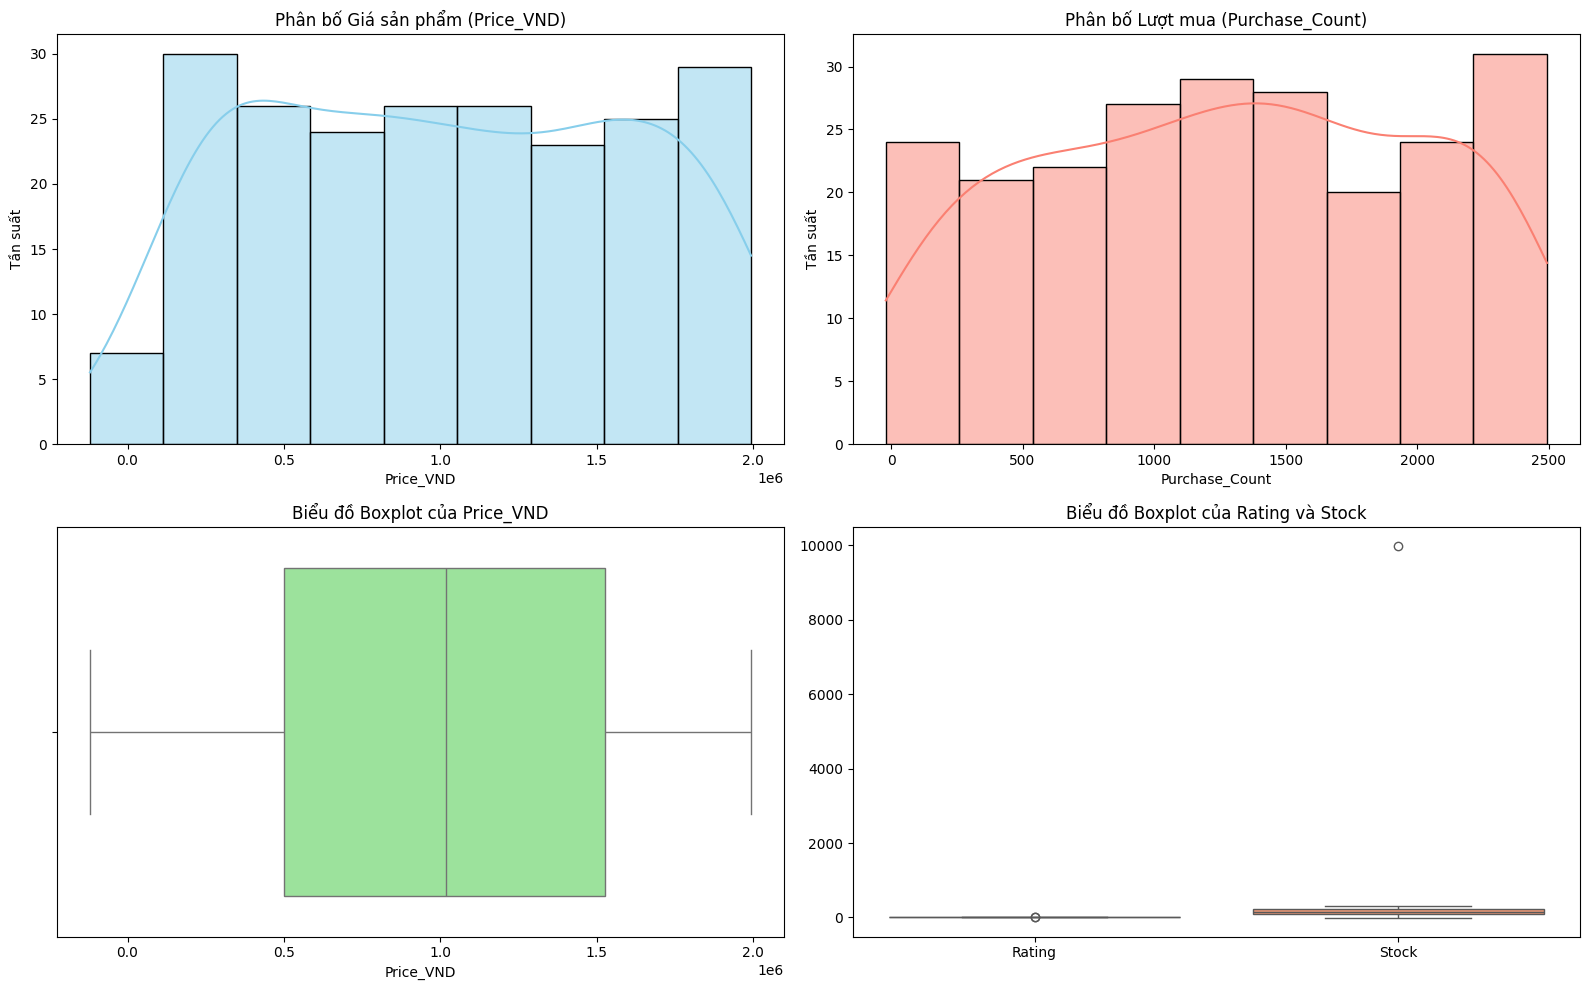

In [17]:
# Bài 4: Trực quan hóa dữ liệu (Histogram & Boxplot)

plt.figure(figsize=(16, 10))

# 1. Histogram cho Price_VND
plt.subplot(2, 2, 1)
sns.histplot(df_num['Price_VND'].dropna(), kde=True, color='skyblue')
plt.title('Phân bố Giá sản phẩm (Price_VND)')
plt.xlabel('Price_VND')
plt.ylabel('Tần suất')

# 2. Histogram cho Purchase_Count
plt.subplot(2, 2, 2)
sns.histplot(df_num['Purchase_Count'].dropna(), kde=True, color='salmon')
plt.title('Phân bố Lượt mua (Purchase_Count)')
plt.xlabel('Purchase_Count')
plt.ylabel('Tần suất')

# 3. Boxplot cho Price_VND
plt.subplot(2, 2, 3)
sns.boxplot(x=df_num['Price_VND'], color='lightgreen')
plt.title('Biểu đồ Boxplot của Price_VND')
plt.xlabel('Price_VND')

# 4. Boxplot cho Rating và Stock
plt.subplot(2, 2, 4)
sns.boxplot(data=df_num[['Rating', 'Stock']], palette='Set2')
plt.title('Biểu đồ Boxplot của Rating và Stock')

plt.tight_layout()
plt.show()